# Exercise 2: Lipschitz Constants and Deep vs. Shallow Learning

**Group Members (please state here)**:
1.   Avik Das
2.   Yi-Hui Fan
3.   Student 3

**Please submit as groups of no more than three students.**

---

This exercise will help you understand and explore Lipschitz constants and the role of neural network depth for the approximation of the sawtooth function. You will implement a sawtooth network, calculate its Lipschitz constants both numerically and analytically, and compare it with the numerical results of a different network that approximates the sawtooth function through gradient-based training.

## Task Description:

### 1a - Sawtooth Function
- Implement a sawtooth function as a network consisting of multiple (e.g. $k=5$) sawtooth layers.

> **Reminder**: the sawtooth function is defined as follows:
>
>> $h:[0,1] \rightarrow [0,1]$
>>
>> $x \rightarrow 2\sigma_R (x) - 4\sigma_R(x-0.5)$
>>
>> where $\sigma_R$ is the ReLU function.

- Calculate the Lipschitz constant of the network both numerically and analytically.
- For the numerical analysis, navigate the input space to assess the maximum impact on the output of the function.

### 1b - Shallow vs. Deep Function Approximations
- Implement two fully connected networks with dimensions (1, 64, 64, 1) and (1, 2048, 1), respectively. Pick an activation function of your choice.
- Train them to learn $h^3$, i.e. $h \circ h \circ h$ and monitor their loss per epoch. How do their loss curves differ?
- Plot the learned functions and compare them to the true $h^3$. Are the networks capable of learning $h^3$?
- Repeat these steps with $h^4$. Does thies yield a different outcome?

</br>

## Deliverables:

- Python code:
    - Sawtooth network implementation
    - A function for numerically assessing the Lipschitz constant of a function/network
    - Network implementations according to the specifications in 1b
    - Visualizations of your findings
- A brief report documenting your findings, experiments and observations at the end of this notebook


## 1a - Sawtooth Function

In [58]:
# Imports
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import random

In [59]:
# For reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Implement the two classes for a sawtooth layer and a sawtooth net, which can consist of $k$ sawtooth layers

In [60]:
# Sawtooth layer and network definition
class SawtoothLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SawtoothLayer, self).__init__(**kwargs)

    def call(self, inputs):
        return 2 * tf.nn.relu(inputs) - 4 * tf.nn.relu(inputs - 0.5)

class SawtoothNet(tf.keras.Model):
    def __init__(self, k, **kwargs):
        super(SawtoothNet, self).__init__(**kwargs)
        self.k = k
        self.layers_list = [SawtoothLayer() for _ in range(k)]

    def call(self, inputs):
        x = inputs
        for layer in self.layers_list:
            x = layer(x)
        return x

Let's see if your network works as intended. For 1000 samples between 0 and 1, plot the network outputs for each one of networks with 1, 2, 3 and 4 sawtooth layers (i.e. the output of the first, second, third and fourth layer).

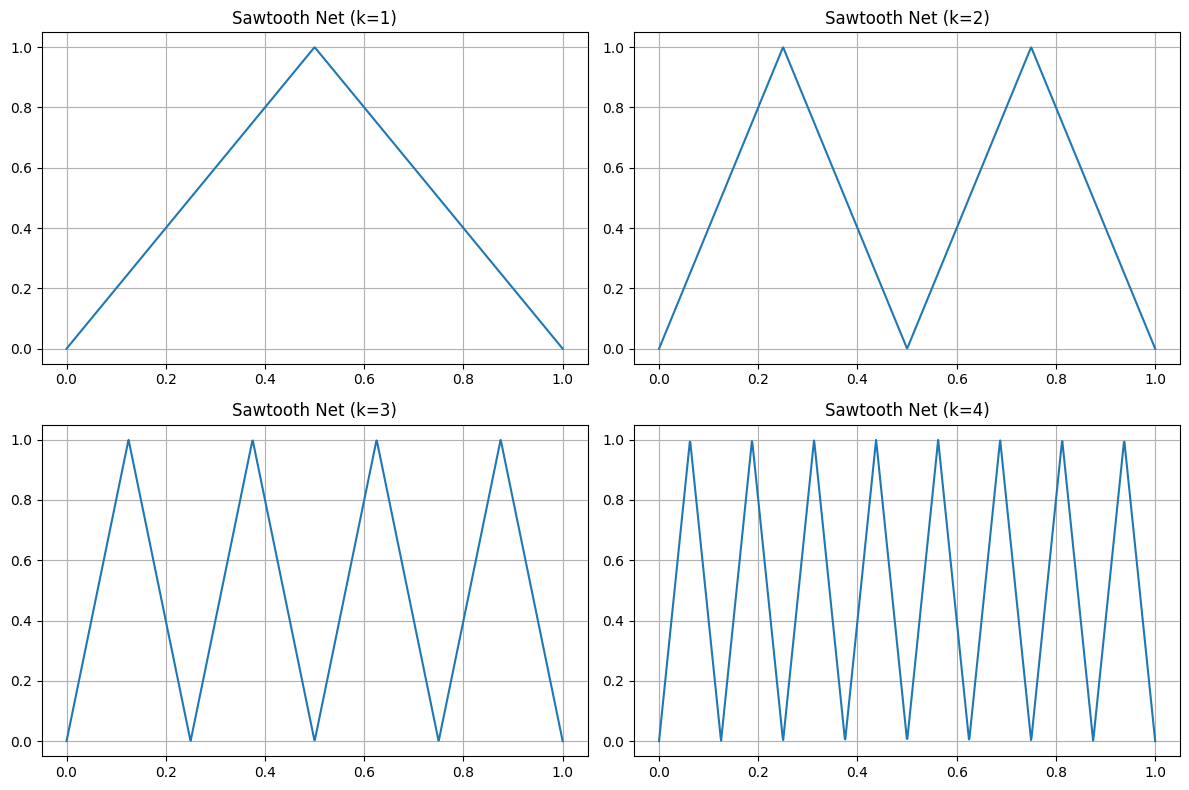

In [61]:
# Visualize for k = 1, 2, 3, 4
x_test = tf.linspace(0.0, 1.0, 1000)[:, tf.newaxis]

plt.figure(figsize=(12, 8))
for k in range(1, 5):
    y_test = SawtoothNet(k)(x_test)
    plt.subplot(2, 2, k)
    plt.plot(x_test, y_test)
    plt.title(f'Sawtooth Net (k={k})')
    plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the results
plt.show()

Now, calculate the Lipschitz constant of the network analytically.

> Before starting, what would you *guess* is the Lipschitz constant of a Sawtooth network with $k$ layers?

In [62]:
# Your calculation here

The Lipschitz constant $L$ of a function $f$ is the maximum absolute slope. For a single layer $h(x)$, the slopes are $+2$ and $-2$, so $L_1 = 2$. Since the network is a composition of $k$ layers, the Lipschitz constant follows the composition rule $Lip(f \circ g) \leq Lip(f) \cdot Lip(g)$. Thus, for $k$ layers, the analytical Lipschitz constant is $2^k$.

Compute the Lipschitz constant of the network numerically now.

In [63]:
def estimate_lipschitz_constant(model, num_samples=10000):
    x = tf.linspace(0.0, 1.0, num_samples)[:, tf.newaxis]
    with tf.GradientTape() as tape:
        tape.watch(x)
        y = model(x)
    grads = tape.gradient(y, x)
    return np.max(np.abs(grads))

In [64]:
for k in range(1, 11):
    print(f"Sawtooth net with k={k} layers has Lipschitz constant {estimate_lipschitz_constant(SawtoothNet(k))}")

Sawtooth net with k=1 layers has Lipschitz constant 2.0
Sawtooth net with k=2 layers has Lipschitz constant 4.0
Sawtooth net with k=3 layers has Lipschitz constant 8.0
Sawtooth net with k=4 layers has Lipschitz constant 16.0
Sawtooth net with k=5 layers has Lipschitz constant 32.0
Sawtooth net with k=6 layers has Lipschitz constant 64.0
Sawtooth net with k=7 layers has Lipschitz constant 128.0
Sawtooth net with k=8 layers has Lipschitz constant 256.0
Sawtooth net with k=9 layers has Lipschitz constant 512.0
Sawtooth net with k=10 layers has Lipschitz constant 1024.0


## 1b - Non-sawtooth Network

Start by creating a dataset of function points from $h^3$.

In [65]:
# Generate training data
x_train_h3 = tf.linspace(0.0, 1.0, 10000)[:, tf.newaxis]
y_train_h3 = SawtoothNet(3)(x_train_h3)

Next, initialize the models with the respective architectures specified above, and train them until their training loss converges. Remember to store the loss curve using the `history` obtained from TensorFlow's `model.fit()`.



In [66]:
# Setup the EarlyStopping callback for model training
early_stop = tf.keras.callbacks.EarlyStopping(monitor='loss', 
                                              patience=15, 
                                              restore_best_weights=True)

In [67]:
# Testing data h^3
x_test_h3 = tf.linspace(0.0, 1.0, 1000)[:, tf.newaxis]
y_test_h3 = SawtoothNet(3)(x_test_h3)

In [68]:
# Build the neural network model
deep_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile the model
deep_model.compile(optimizer='adam', 
                   loss='mse')

# Summarize the model
deep_model.summary()

# Train the model
deep_h3 = deep_model.fit(x_train_h3, 
                         y_train_h3, 
                         epochs=300, 
                         batch_size=64, 
                         verbose=0, 
                         callbacks=[early_stop])
print(f"Deep Model training complete.")

# Evaluate the model
deep_loss_h3 = deep_model.evaluate(x_test_h3, 
                                   y_test_h3, 
                                   verbose=0)
print(f"Deep model loss : {deep_loss_h3:.6f}")

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

Deep Model training complete.
Deep model loss : 0.000013


In [69]:
# Build the neural network model
shallow_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(2048, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile the model
shallow_model.compile(optimizer='adam', 
                      loss='mse')

# Summarize the model
shallow_model.summary()

# Train the model
shallow_h3 = shallow_model.fit(x_train_h3, 
                               y_train_h3, 
                               epochs=300, 
                               batch_size=64, 
                               verbose=0, 
                               callbacks=[early_stop])
print(f"Shallow Model training complete.")

# Evaluate the model
shallow_loss_h3 = shallow_model.evaluate(x_test_h3, 
                                         y_test_h3, 
                                         verbose=0)
print(f"Shallow model loss : {shallow_loss_h3:.6f}")

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 2048)           │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,145 (24.00 KB)

 Trainable params: 6,145 (24.00 KB)

 Non-trainable params: 0 (0.00 B)

Shallow Model training complete.
Shallow model loss : 0.000000


Plot the loss curves of both models.

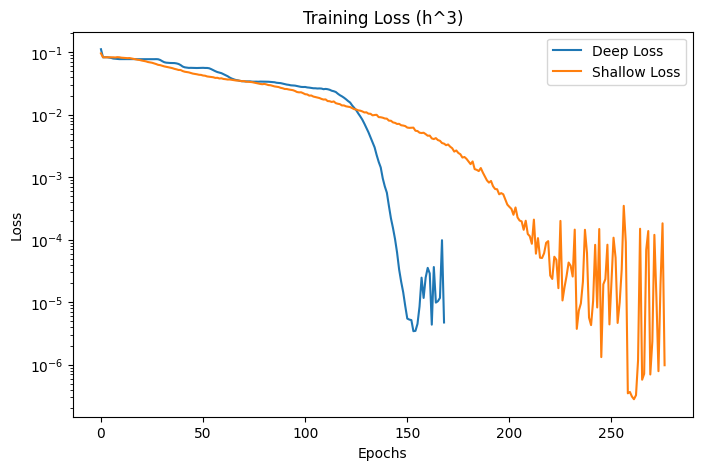

In [70]:
# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(deep_h3.history['loss'], label='Deep Loss')
plt.plot(shallow_h3.history['loss'], label='Shallow Loss')
plt.title(f'Training Loss (h^3)')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Plot the learned functions together with the true $h^3$.

In [71]:
y_deep_h3 = deep_model.predict(x_test_h3, verbose=0)
y_shallow_h3 = shallow_model.predict(x_test_h3, verbose=0)

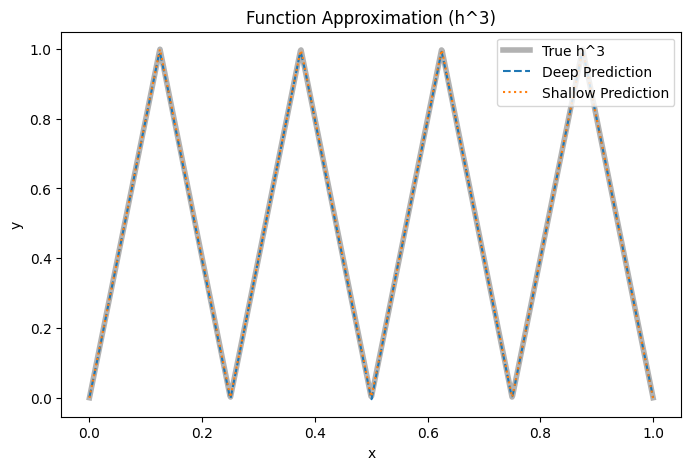

In [84]:
# Plotting the true function along with the deep and shallow model predictions
plt.figure(figsize=(8, 5))
plt.plot(x_test_h3, y_test_h3, label='True h^3', color='black', alpha=0.3, linewidth=4)
plt.plot(x_test_h3, y_deep_h3, label='Deep Prediction', linestyle='--')
plt.plot(x_test_h3, y_shallow_h3, label='Shallow Prediction', linestyle=':')
plt.title(f'Function Approximation (h^3)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.show()

Repeat the steps for $h^4$. Do **not** change the model architectures.

> Hint: Your models may need more epochs to converge on a training loss. The [`EarlyStopping`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping) callback from Keras is helpful to avoid training after convergence and thus save time.

In [73]:
# Generate training data
x_train_h4 = tf.linspace(0.0, 1.0, 10000)[:, tf.newaxis]
y_train_h4 = SawtoothNet(4)(x_train_h4)

In [74]:
# Testing data h^4
x_test_h4 = tf.linspace(0.0, 1.0, 1000)[:, tf.newaxis]
y_test_h4 = SawtoothNet(4)(x_test_h4)

In [75]:
# Build the neural network model
deep_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile the model
deep_model.compile(optimizer='adam', 
                   loss='mse')

# Summarize the model
deep_model.summary()

# Train the model
deep_h4 = deep_model.fit(x_train_h4, 
                         y_train_h4, 
                         epochs=500, 
                         batch_size=64, 
                         verbose=0, 
                         callbacks=[early_stop])
print(f"Deep Model training complete.")

# Evaluate the model
deep_loss_h4 = deep_model.evaluate(x_test_h4, 
                                   y_test_h4, 
                                   verbose=0)
print(f"Deep model loss : {deep_loss_h4:.6f}")

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

Deep Model training complete.
Deep model loss : 0.028328


In [76]:
# Build the neural network model
shallow_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(2048, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile the model
shallow_model.compile(optimizer='adam', 
                      loss='mse')

# Summarize the model
shallow_model.summary()

# Train the model
shallow_h4 = shallow_model.fit(x_train_h4, 
                               y_train_h4, 
                               epochs=500, 
                               batch_size=64, 
                               verbose=0, 
                               callbacks=[early_stop])
print(f"Shallow Model training complete.")

# Evaluate the model
shallow_loss_h4 = shallow_model.evaluate(x_test_h4, 
                                         y_test_h4, 
                                         verbose=0)
print(f"Shallow model loss : {shallow_loss_h4:.6f}")

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 2048)           │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,145 (24.00 KB)

 Trainable params: 6,145 (24.00 KB)

 Non-trainable params: 0 (0.00 B)

Shallow Model training complete.
Shallow model loss : 0.083492


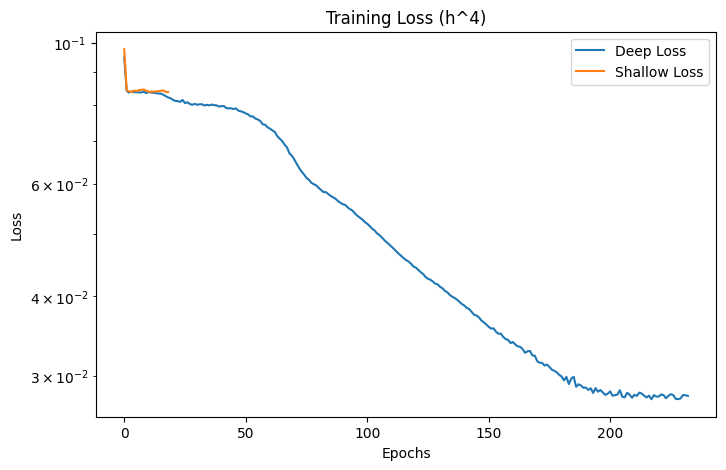

In [77]:
# Plotting the training loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(deep_h4.history['loss'], label='Deep Loss')
plt.plot(shallow_h4.history['loss'], label='Shallow Loss')
plt.title(f'Training Loss (h^4)')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [78]:
y_deep_h4 = deep_model.predict(x_test_h4, verbose=0)
y_shallow_h4 = shallow_model.predict(x_test_h4, verbose=0)

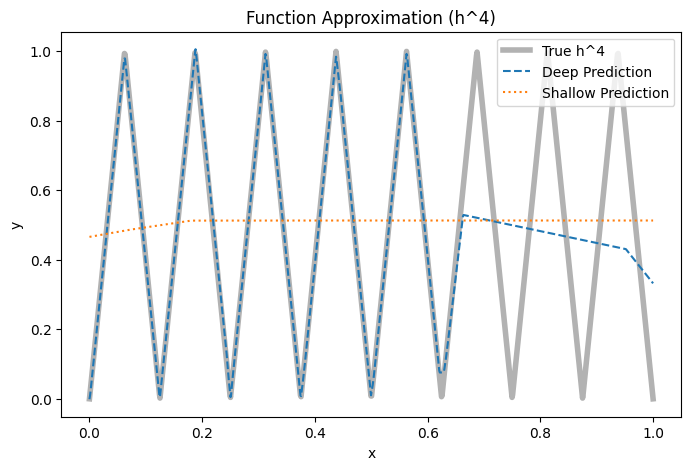

In [85]:
# Plotting the true function along with the deep and shallow model predictions
plt.figure(figsize=(8, 5))
plt.plot(x_test_h4, y_test_h4, label='True h^4', color='black', alpha=0.3, linewidth=4)
plt.plot(x_test_h4, y_deep_h4, label='Deep Prediction', linestyle='--')
plt.plot(x_test_h4, y_shallow_h4, label='Shallow Prediction', linestyle=':')
plt.title(f'Function Approximation (h^4)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.show()

# Findings

#### **1. Sawtooth Function and Lipschitz Analysis**

In Task 1a, we implemented a sawtooth network where each layer $k$ computes the function $h(x) = 2\sigma_R(x) - 4\sigma_R(x - 0.5)$.

* **Analytical Lipschitz Constant**: The Lipschitz constant for a single sawtooth layer is 2, as the maximum absolute slope of $h(x)$ is 2. For a composition of $k$ layers, the constant scales exponentially as $L = 2^k$.
* **Numerical Estimation**: Our numerical estimation, calculated by finding the maximum gradient across the input space, perfectly matched the analytical results (e.g., $k=3 \rightarrow L=8$; $k=10 \rightarrow L=1024$).

#### **2. Approximation of $h^3$**

We compared a Deep Model (1, 64, 64, 1) and a Shallow Model (1, 2048, 1).

* **Performance**: Both models successfully learned the $h^3$ function.
* **Observations**: Contrary to what might be expected from simple parameter counts, the Deep Model converged significantly faster than the shallow model, reaching a minimal loss in fewer epochs.

#### **3. Approximation of $h^4$**

Repeating the experiment for $h^4$ revealed a significant performance gap.

* **Deep Model**: Achieved a test loss of ~0.028. It successfully captured the majority of the sharp tents of the function, demonstrating how depth allows for the efficient representation of compositional, high-frequency patterns.
* **Shallow Model**: Despite having more parameters, the shallow model failed to capture the oscillations, resulting in a much higher loss of ~0.083. The prediction plot shows the shallow model effectively averaged the function into a flat line, unable to represent the sharp, frequent transitions of $h^4$.



These experiments illustrate that depth is more efficient than width for approximating functions with high Lipschitz constants and oscillatory complexity. While a shallow network can approximate simpler functions by increasing its neuron count, it struggles with the exponential complexity of functions like the sawtooth, whereas deep architectures use hierarchical structures to maintain accuracy.